In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
import sklearn
import matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


folder_path = "/content/drive/MyDrive/Colab Notebooks/"

Mounted at /content/drive


In [ ]:
Cs = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Adra1a eLacco fiberphoto.xlsx", sheet_name='test')
Ks = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Adra1a eLacco fiberphoto.xlsx", sheet_name='KO_saline')

In [ ]:
def idx_of_the_nearest(data, value):
  '''
  一番近いインデックスを取得
  '''
  idx = np.argmin(np.abs(np.array(data) - value))

  return idx

In [ ]:
def dFF_func(time, iso, green, BC_start_sec, BC_end_sec, BL_start_sec, BL_end_sec, fitting, mouse):
    '''
    dF/Fを算出する関数
    fitting: 1だったら470でfitting, 0だったら405でfitting
    '''
    BC_start = idx_of_the_nearest(time, BC_start_sec)
    BC_end = idx_of_the_nearest(time, BC_end_sec)

    BL_start = idx_of_the_nearest(time, BL_start_sec)
    BL_end = idx_of_the_nearest(time, BL_end_sec)


    add1 = [1 for i in range(len(green))]

    fit = np.polyfit(time, iso, 1)
    fittedIso = fit[0] * np.array(time) + fit[1]
    isoBC = iso - fittedIso
    isoBCN = isoBC + add1

    fit = np.polyfit(time[BC_start:BC_end], green[BC_start:BC_end], 1)
    fittedGreen = fit[0] * np.array(time) + fit[1]

    if fitting == 1:
        greenBC = green - fittedGreen
        greenBCN = greenBC + add1

    else:
        greenBC = green - fittedIso
        greenBCN = greenBC + add1

    BL_mean = np.mean(greenBCN[BL_start:BL_end] / isoBCN[BL_start:BL_end])
    dFF = greenBCN / isoBCN - BL_mean

    fig_func(time, iso, green, fittedIso, fittedGreen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse)

    return dFF

In [ ]:
def fig_func(time, iso, green, fittedIso, fittedGeen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse):

    plt.figure(figsize=(50, 2))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    #plt.subplot(1, 3, 1)
    #plt.plot(time, iso, color="gray")
    #plt.plot(time, green, color="black")

    if fitting == 1:
        plt.plot(time[BC_start:BC_end], green[BC_start:BC_end], color="red")
        plt.plot(time, fittedIso, color="blue")

    if fitting == 1:
        plt.plot(time, fittedGeen, color="blue")
    else:
        plt.plot(time, fittedIso, color="blue")


    #plt.subplot(1, 3, 2)
    #plt.plot(time, isoBCN, color="gray")
    #plt.plot(time, greenBCN, color="black")

    plt.subplot(1, 3, 3)
    plt.plot(time, dFF, color="green")
    plt.plot(time[BL_start:BL_end], dFF[BL_start:BL_end], color='red')

    plt.title('{}'.format(mouse))

In [ ]:
time_ = [float(_) for _ in np.array(Cs.filter(like=('Time'), axis=1))][10:-9]

/tmp/ipykernel_573/3970037367.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time_ = [float(_) for _ in np.array(Cs.filter(like=('Time'), axis=1))][10:-9]


In [ ]:
Cont1_saline = np.array(Cs.filter(['Cont1_iso', 'Cont1_green']))[10:-9]
Cont2_saline = np.array(Cs.filter(['Cont2_iso', 'Cont2_green']))[10:-9]
Cont3_saline = np.array(Cs.filter(['Cont3_iso', 'Cont3_green']))[10:-9]
Cont4_saline = np.array(Cs.filter(['Cont4_iso', 'Cont4_green']))[10:-9]
Cont5_saline = np.array(Cs.filter(['Cont5_iso', 'Cont5_green']))[10:-9]
Cont6_saline = np.array(Cs.filter(['Cont6_iso', 'Cont6_green']))[10:-9]
Cont7_saline = np.array(Cs.filter(['Cont7_iso', 'Cont7_green']))[10:-9]
Cont8_saline = np.array(Cs.filter(['Cont8_iso', 'Cont8_green']))[10:-9]

In [ ]:
KO1_saline = np.array(Ks.filter(['KO1_iso', 'KO1_green']))[10:-9]
KO2_saline = np.array(Ks.filter(['KO2_iso', 'KO2_green']))[10:-9]
KO3_saline = np.array(Ks.filter(['KO3_iso', 'KO3_green']))[10:-9]
KO4_saline = np.array(Ks.filter(['KO4_iso', 'KO4_green']))[10:-9]
KO5_saline = np.array(Ks.filter(['KO5_iso', 'KO5_green']))[10:-9]
KO6_saline = np.array(Ks.filter(['KO6_iso', 'KO6_green']))[10:-9]
KO7_saline = np.array(Ks.filter(['KO7_iso', 'KO7_green']))[10:-9]
KO8_saline = np.array(Ks.filter(['KO8_iso', 'KO8_green']))[10:-9]
KO9_saline = np.array(Ks.filter(['KO9_iso', 'KO9_green']))[10:-9]

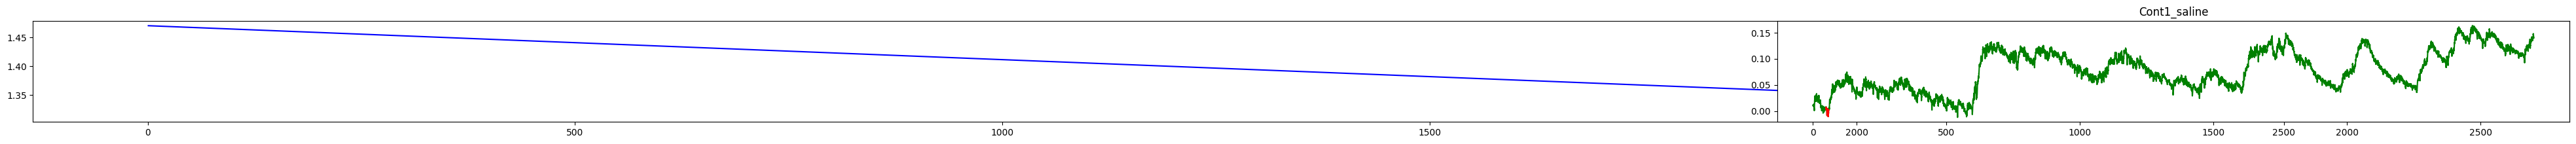

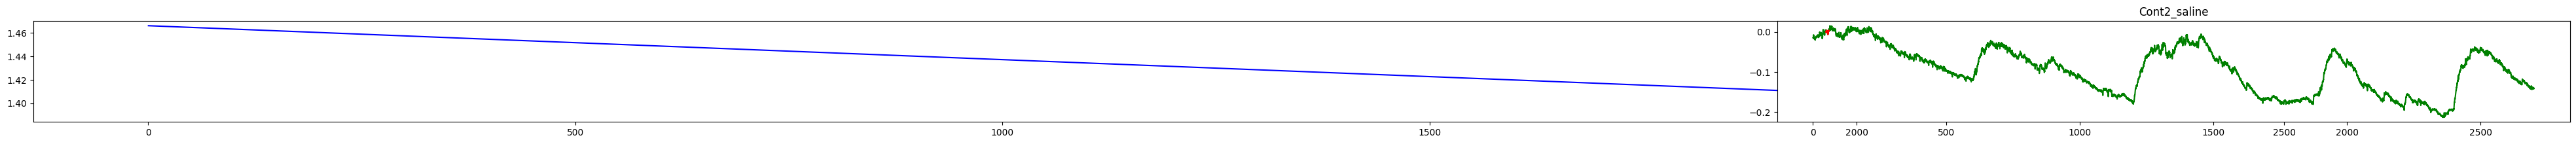

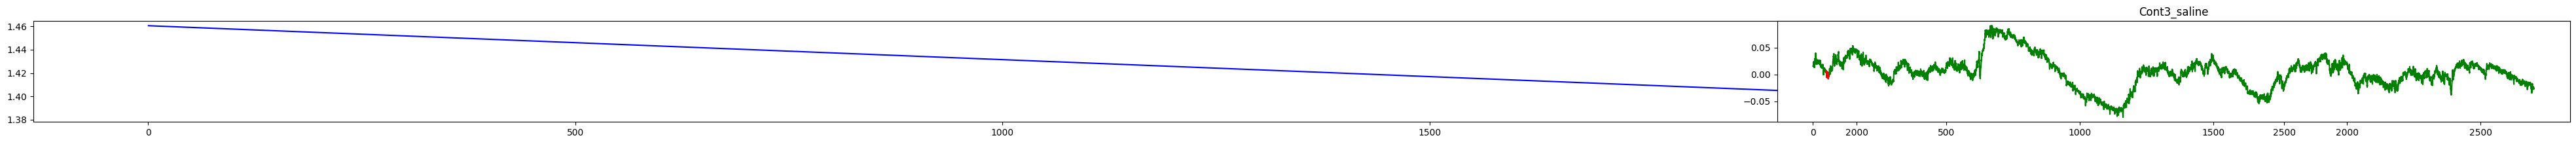

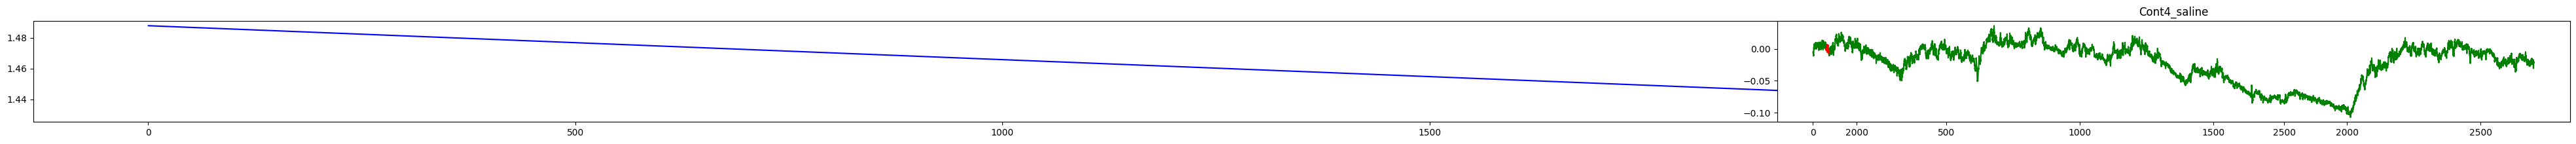

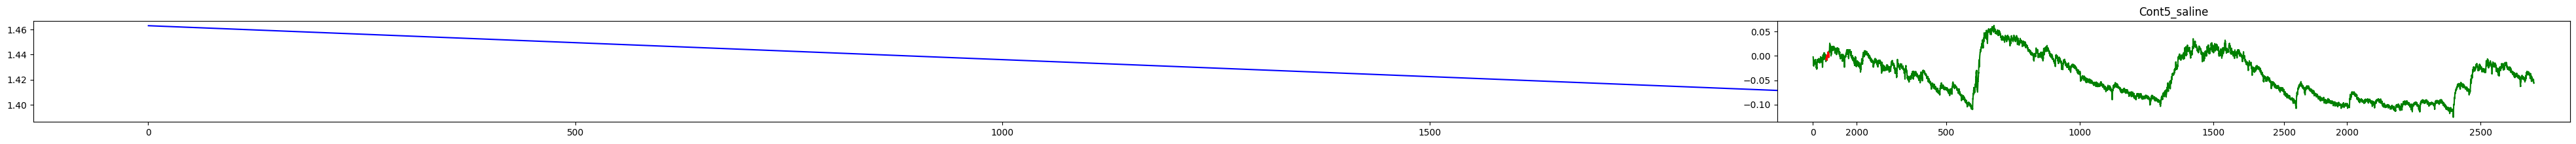

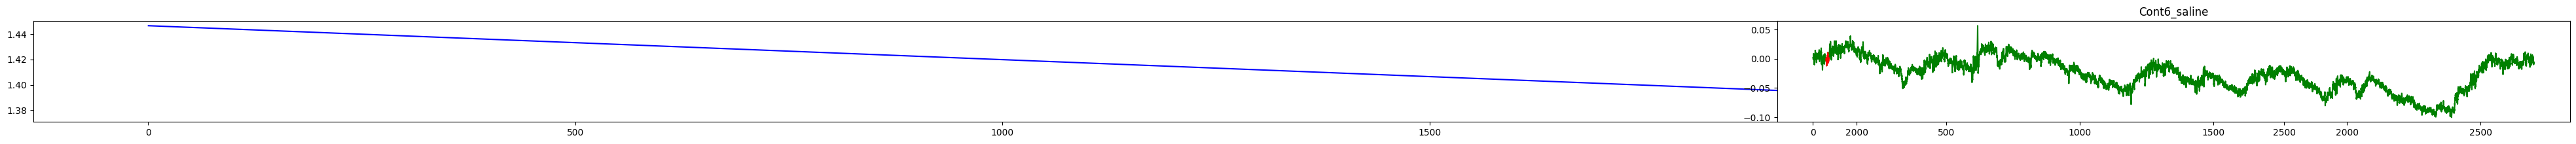

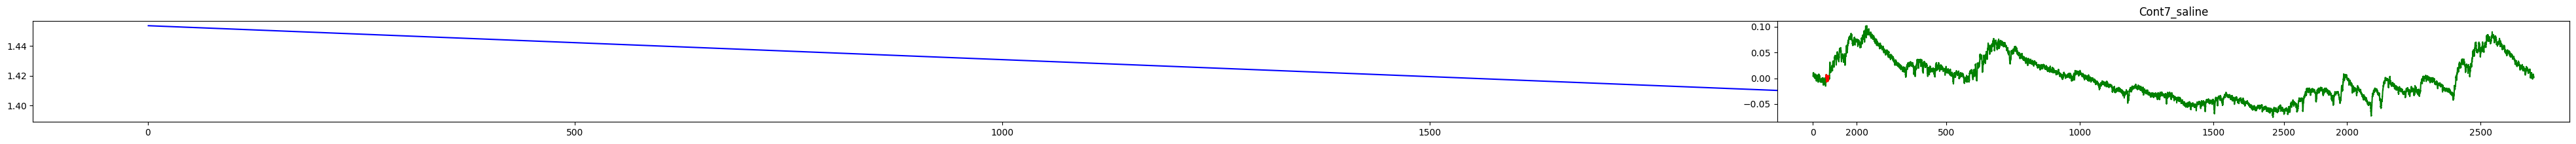

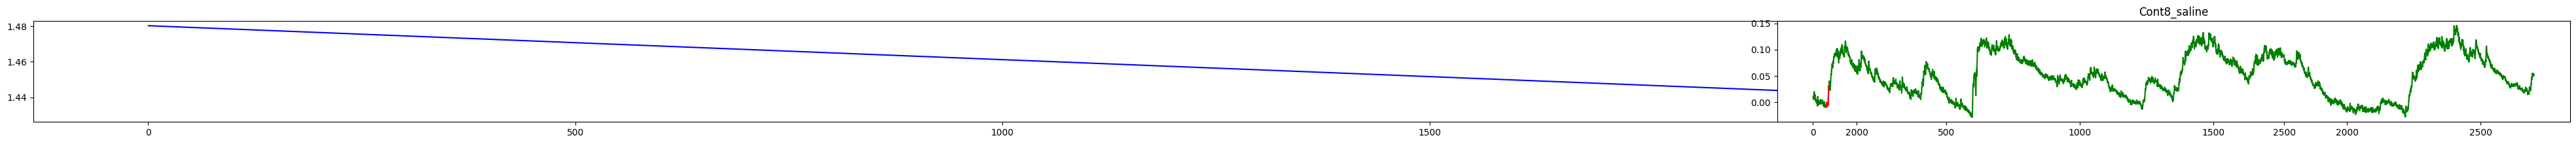

In [ ]:
Cont1_saline_dFF = dFF_func(time_, Cont1_saline[:,0], Cont1_saline[:,1], 0, 2700, 49, 59, 0, "Cont1_saline")
Cont2_saline_dFF = dFF_func(time_, Cont2_saline[:,0], Cont2_saline[:,1], 0, 2700, 49, 59, 0, "Cont2_saline")
Cont3_saline_dFF = dFF_func(time_, Cont3_saline[:,0], Cont3_saline[:,1], 0, 2700, 49, 59, 0, "Cont3_saline")
Cont4_saline_dFF = dFF_func(time_, Cont4_saline[:,0], Cont4_saline[:,1], 0, 2700, 49, 59, 0, "Cont4_saline")
Cont5_saline_dFF = dFF_func(time_, Cont5_saline[:,0], Cont5_saline[:,1], 0, 2700, 49, 59, 0, "Cont5_saline")
Cont6_saline_dFF = dFF_func(time_, Cont6_saline[:,0], Cont6_saline[:,1], 0, 2700, 49, 59, 0, "Cont6_saline")
Cont7_saline_dFF = dFF_func(time_, Cont7_saline[:,0], Cont7_saline[:,1], 0, 2700, 49, 59, 0, "Cont7_saline")
Cont8_saline_dFF = dFF_func(time_, Cont8_saline[:,0], Cont8_saline[:,1], 0, 2700, 49, 59, 0, "Cont8_saline")

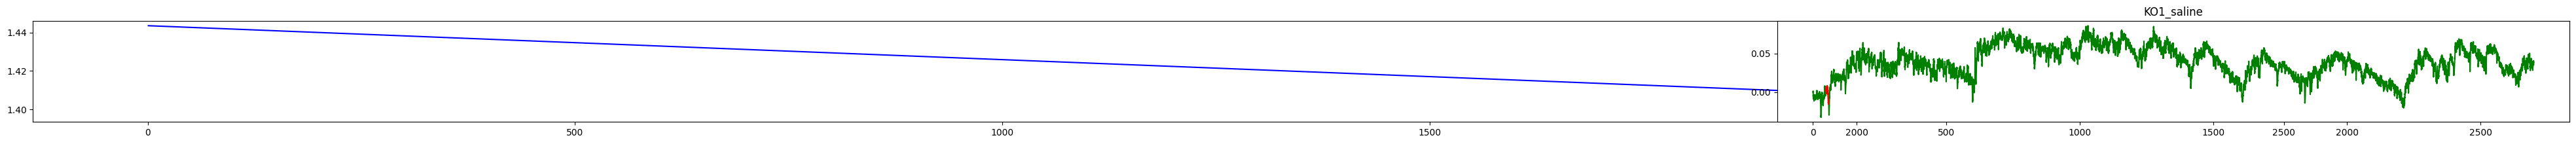

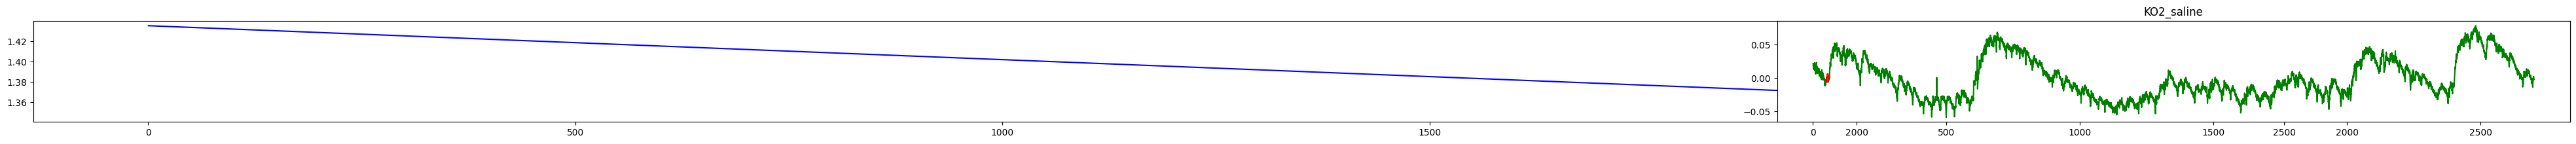

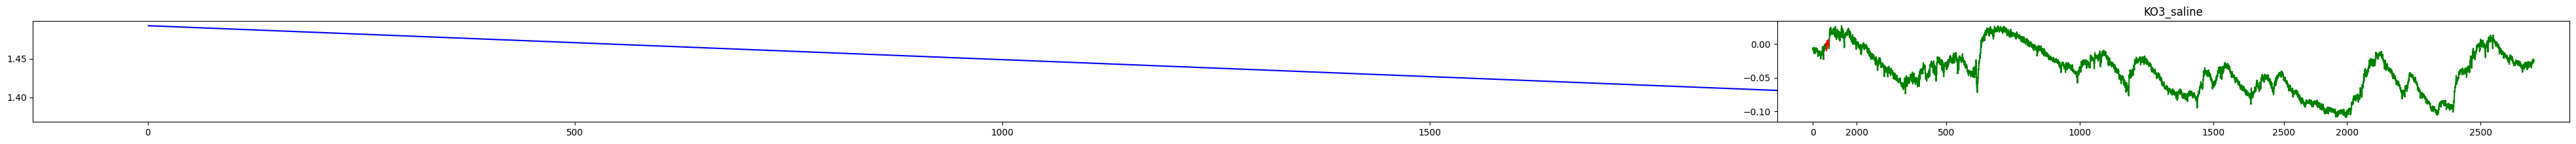

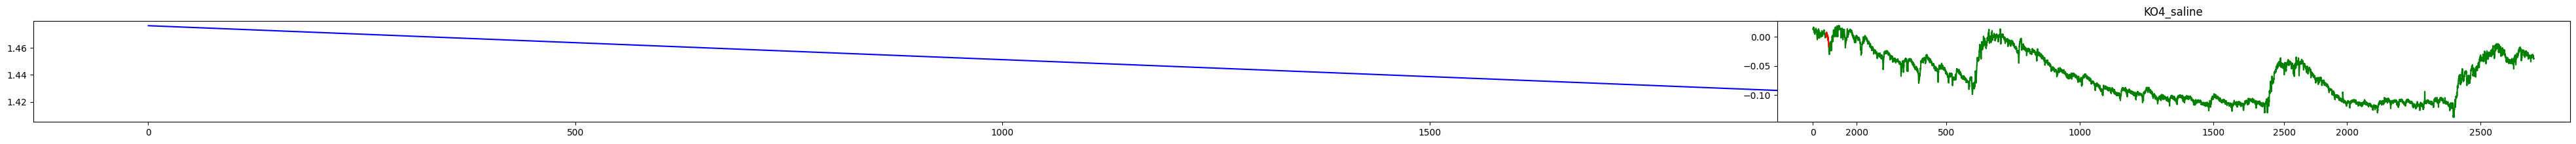

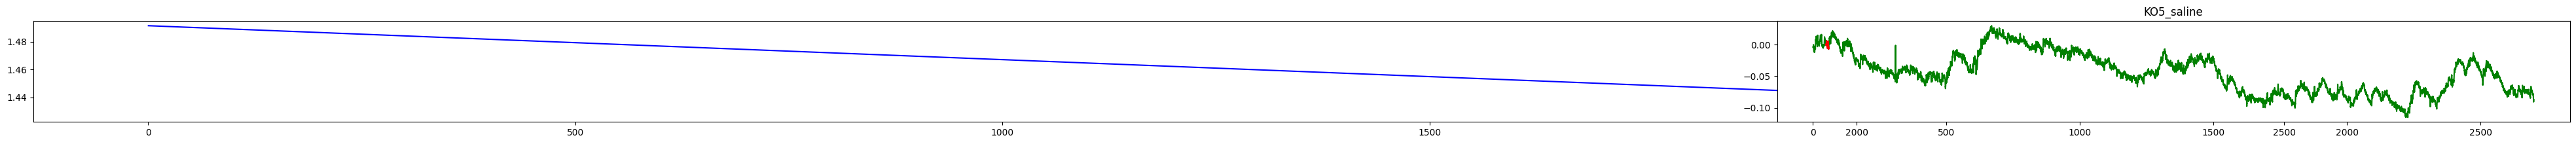

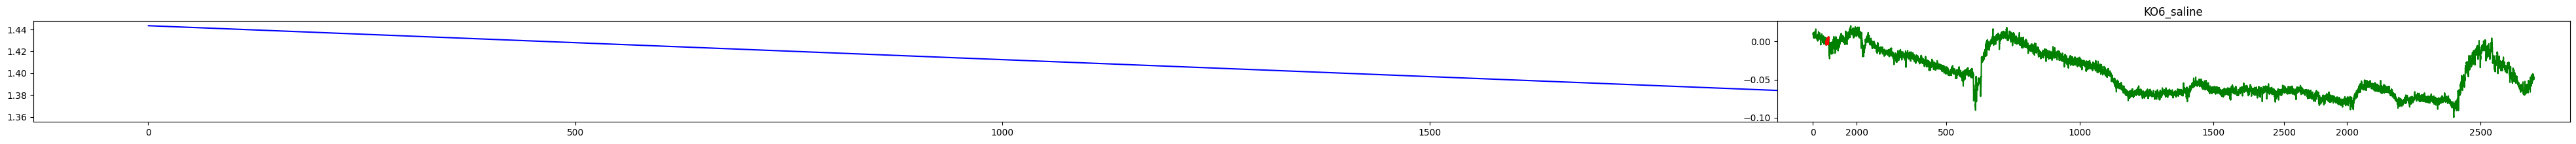

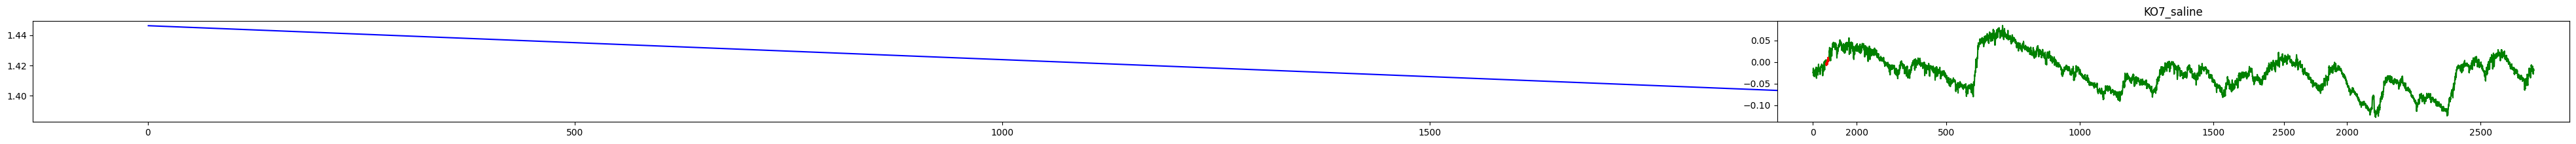

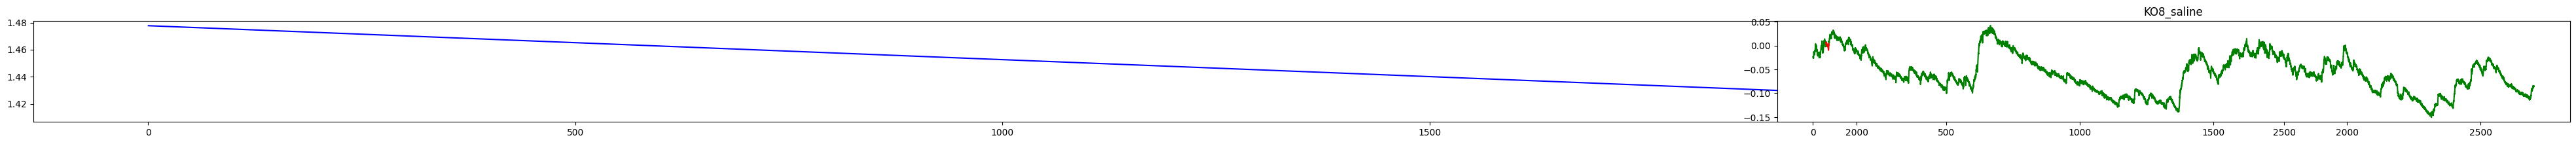

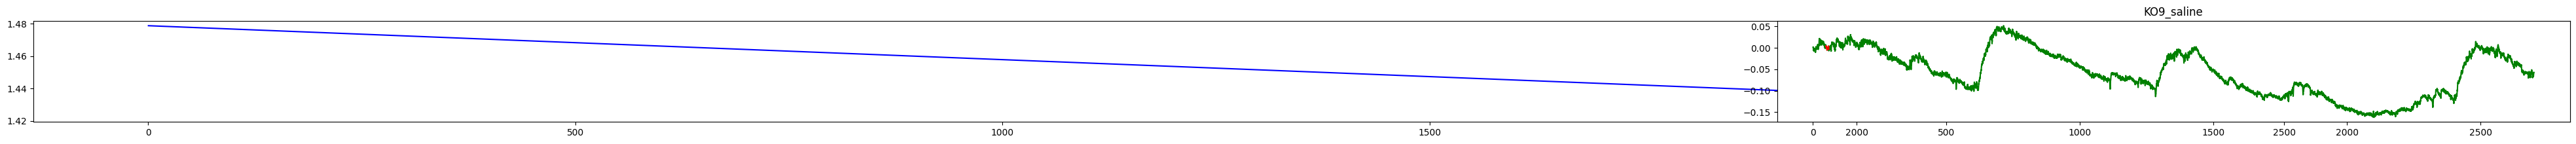

In [ ]:
KO1_saline_dFF = dFF_func(time_, KO1_saline[:,0], KO1_saline[:,1], 0, 2700, 49, 59, 0, "KO1_saline")
KO2_saline_dFF = dFF_func(time_, KO2_saline[:,0], KO2_saline[:,1], 0, 2700, 49, 59, 0, "KO2_saline")
KO3_saline_dFF = dFF_func(time_, KO3_saline[:,0], KO3_saline[:,1], 0, 2700, 49, 59, 0, "KO3_saline")
KO4_saline_dFF = dFF_func(time_, KO4_saline[:,0], KO4_saline[:,1], 0, 2700, 49, 59, 0, "KO4_saline")
KO5_saline_dFF = dFF_func(time_, KO5_saline[:,0], KO5_saline[:,1], 0, 2700, 49, 59, 0, "KO5_saline")
KO6_saline_dFF = dFF_func(time_, KO6_saline[:,0], KO6_saline[:,1], 0, 2700, 49, 59, 0, "KO6_saline")
KO7_saline_dFF = dFF_func(time_, KO7_saline[:,0], KO7_saline[:,1], 0, 2700, 49, 59, 0, "KO7_saline")
KO8_saline_dFF = dFF_func(time_, KO8_saline[:,0], KO8_saline[:,1], 0, 2700, 49, 59, 0, "KO8_saline")
KO9_saline_dFF = dFF_func(time_, KO9_saline[:,0], KO9_saline[:,1], 0, 2700, 49, 59, 0, "KO9_saline")

In [ ]:
Cont_saline_dFF = pd.DataFrame([Cont1_saline_dFF, Cont2_saline_dFF, Cont3_saline_dFF, Cont5_saline_dFF, Cont6_saline_dFF, Cont7_saline_dFF, Cont8_saline_dFF]).T

Cont_saline_dFF.columns = ["Cont1_saline", "Cont2_saline", "Cont3_saline", "Cont5_saline", "Cont6_saline", "Cont7_saline", "Cont8_saline"]
Cont_saline_dFF.index = time_


In [ ]:
KO_saline_dFF = pd.DataFrame([KO1_saline_dFF, KO2_saline_dFF, KO3_saline_dFF, KO4_saline_dFF, KO5_saline_dFF, KO6_saline_dFF, KO7_saline_dFF, KO8_saline_dFF, KO9_saline_dFF]).T

KO_saline_dFF.columns = ["KO1_saline", "KO2_saline", "KO3_saline", "KO4_saline", "KO5_saline", "KO6_saline", "KO7_saline", "KO8_saline", "KO9_saline"]
KO_saline_dFF.index = time_

# Adra1a analysis peak

In [ ]:
#puff1_start_pre, puff1_end_pre = idx_of_the_nearest(time_, 48), idx_of_the_nearest(time_, 117)+1
#puff2_start_pre, puff2_end_pre = idx_of_the_nearest(time_, 118), idx_of_the_nearest(time_, 177)+1
#puff3_start_pre, puff3_end_pre = idx_of_the_nearest(time_, 178), idx_of_the_nearest(time_, 237)+1

puff1_start_pre, puff1_end_pre = idx_of_the_nearest(time_, 2388), idx_of_the_nearest(time_, 2457)+1
puff2_start_pre, puff2_end_pre = idx_of_the_nearest(time_, 2458), idx_of_the_nearest(time_, 2517)+1
puff3_start_pre, puff3_end_pre = idx_of_the_nearest(time_, 2518), idx_of_the_nearest(time_, 2577)+1

### Adra1a Control no cre

In [ ]:
def peak_func(dFF_data, peakInd):
    return [
        float(dFF_data.loc[peakInd[i], mouse])
        for i, mouse in enumerate(dFF_data.columns)
    ]

In [ ]:
Cont_saline_puff1_peakInd_pre = Cont_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
Cont_saline_puff2_peakInd_pre = Cont_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
Cont_saline_puff3_peakInd_pre = Cont_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

/tmp/ipykernel_62749/3242947073.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
/tmp/ipykernel_62749/3242947073.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
/tmp/ipykernel_62749/3242947073.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior)

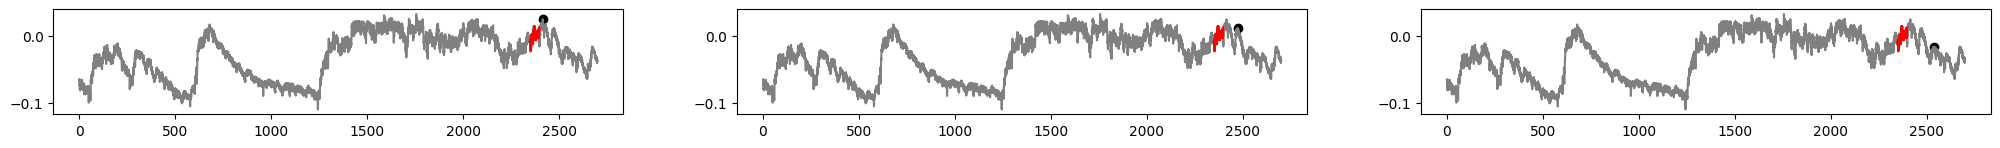

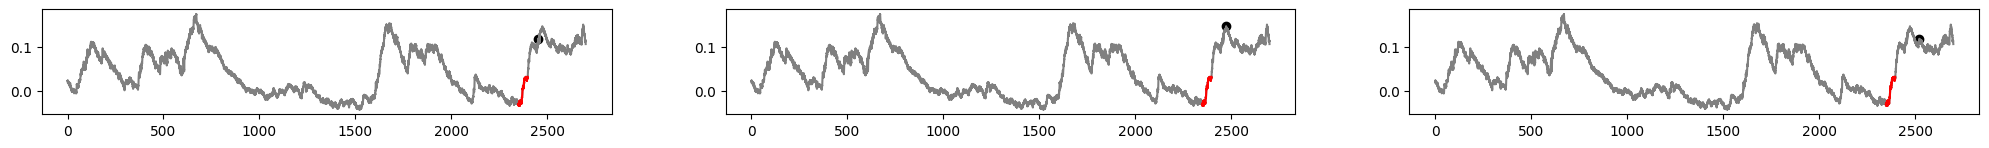

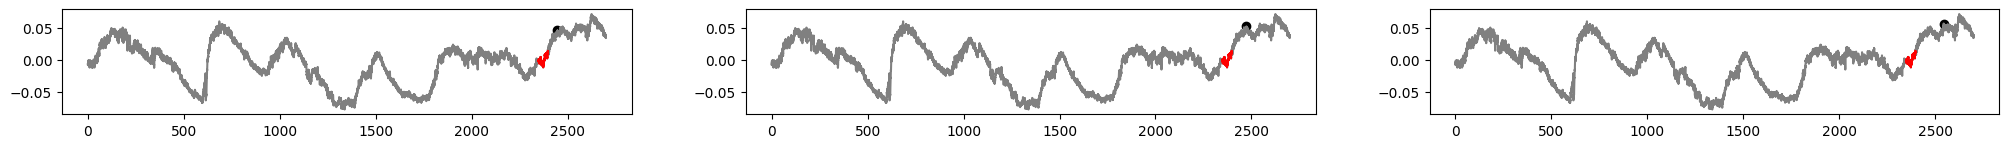

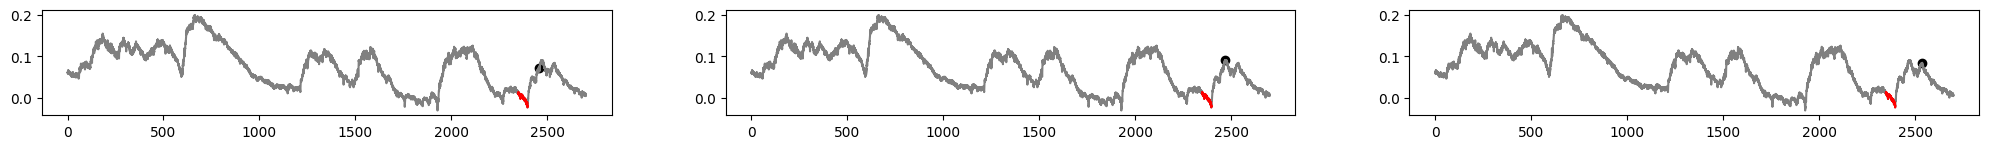

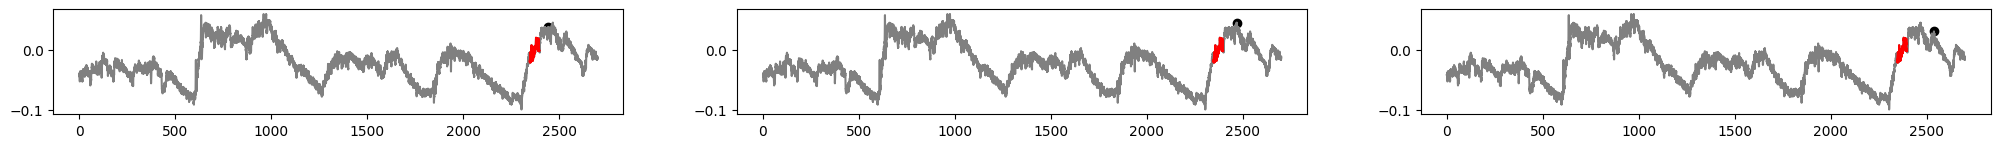

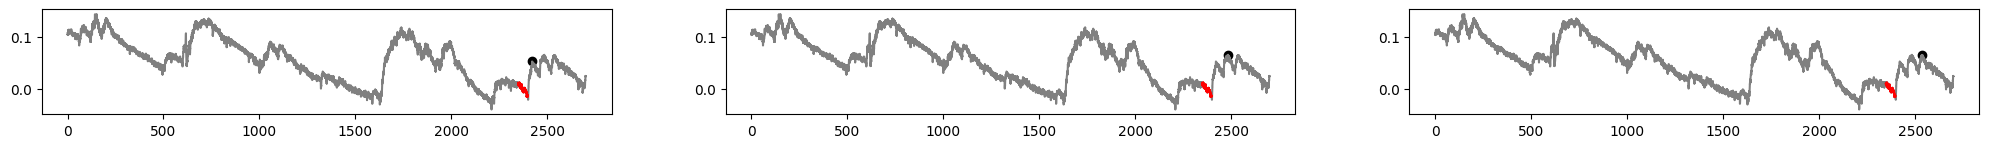

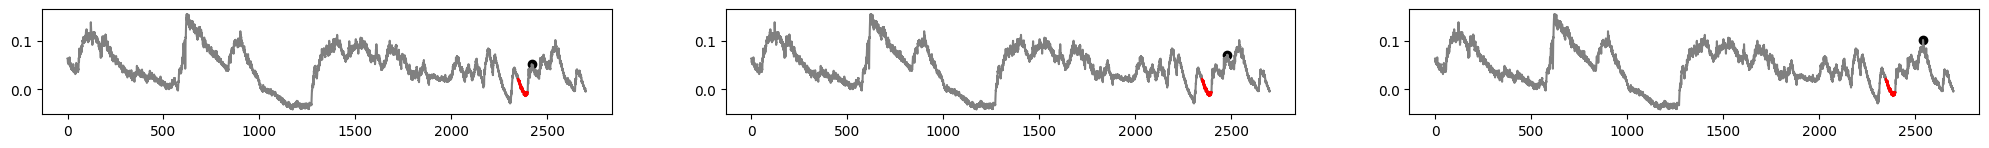

In [ ]:
for i,c in enumerate(Cont_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i], color="gray")
    ax1.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(Cont_saline_puff1_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i], color="gray")
    ax2.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(Cont_saline_puff2_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i].index, Cont_saline_dFF.iloc[:idx_of_the_nearest(time_, 2700),i], color="gray")
    ax3.plot(Cont_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(Cont_saline_puff3_peakInd_pre[i], Cont_saline_dFF.loc[Cont_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff1_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[0.02507106703151396,
 0.11904119428415694,
 0.0457064386931163,
 0.07200603929515814,
 0.038469631872671384,
 0.053111727362954886,
 0.052253067428007616]

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff2_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[0.01167264655806255,
 0.14716381163706727,
 0.05192829701949364,
 0.09104916772576399,
 0.045682179101180775,
 0.06589792003238859,
 0.0718365878952536]

In [ ]:
peak_func(Cont_saline_dFF, Cont_saline_puff3_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[-0.016029647434226302,
 0.11847541695859243,
 0.05642128913180522,
 0.08487742883628713,
 0.030998866200979025,
 0.06530648295508112,
 0.10213111882981663]

In [ ]:
Cont_saline_dFF.to_excel('/content/drive/MyDrive/Cont_saline_dFF.xlsx')

### Adra1a KO with cre

In [ ]:
KO_saline_puff1_peakInd_pre = KO_saline_dFF.iloc[puff1_start_pre:puff1_end_pre,:].idxmax()
KO_saline_puff2_peakInd_pre = KO_saline_dFF.iloc[puff2_start_pre:puff2_end_pre,:].idxmax()
KO_saline_puff3_peakInd_pre = KO_saline_dFF.iloc[puff3_start_pre:puff3_end_pre,:].idxmax()

/tmp/ipykernel_62749/3347736202.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(KO_saline_puff1_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff1_peakInd_pre[i],c], color="black")
/tmp/ipykernel_62749/3347736202.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(KO_saline_puff2_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff2_peakInd_pre[i],c], color="black")
/tmp/ipykernel_62749/3347736202.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access 

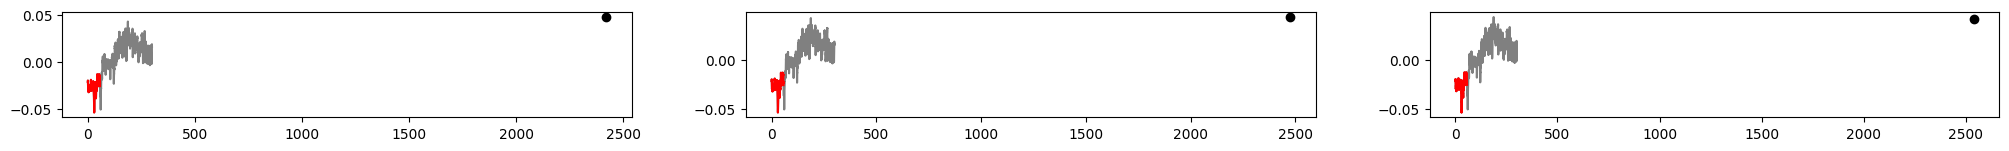

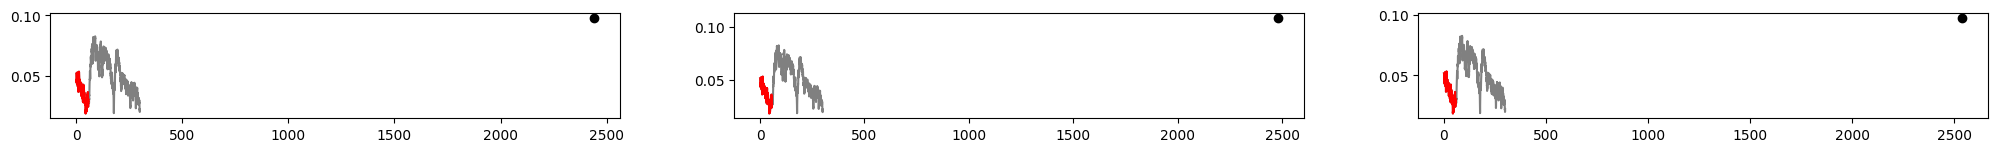

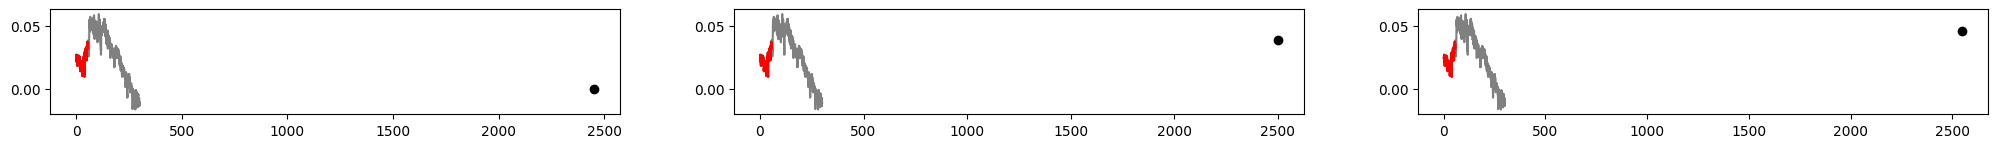

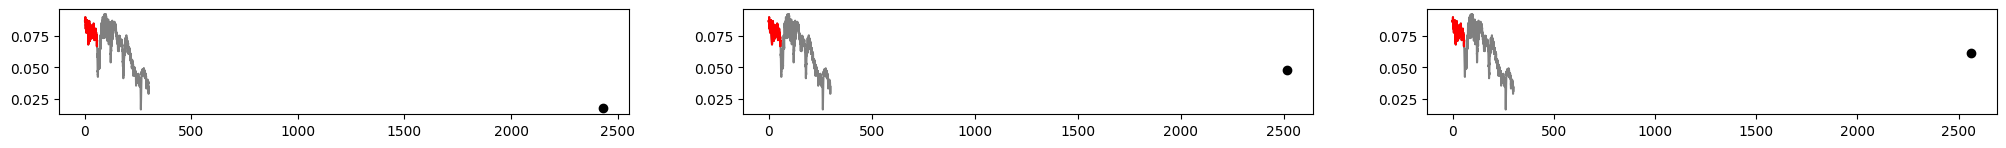

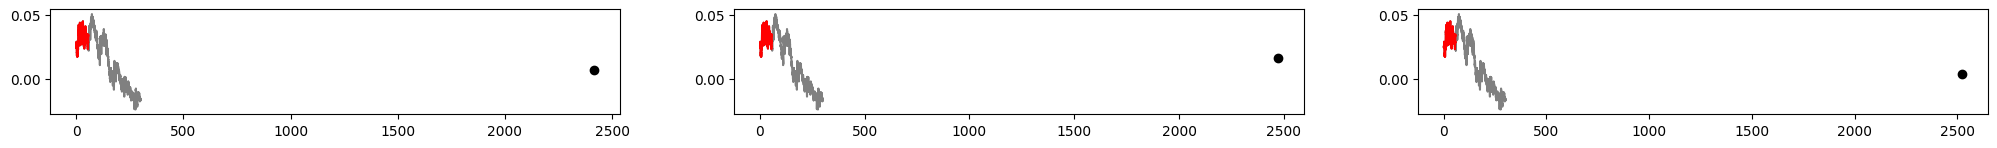

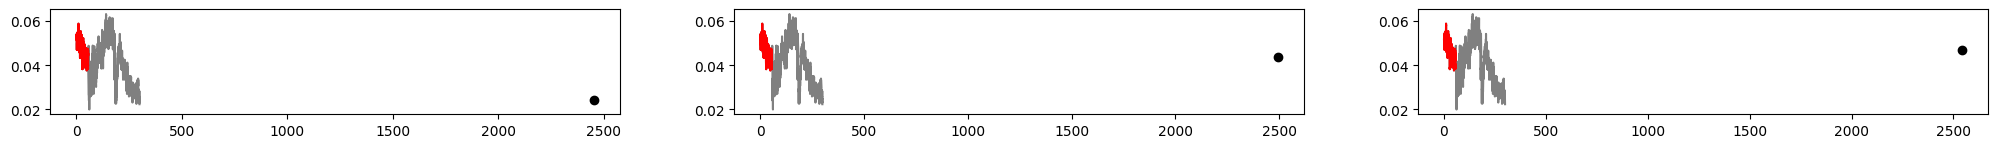

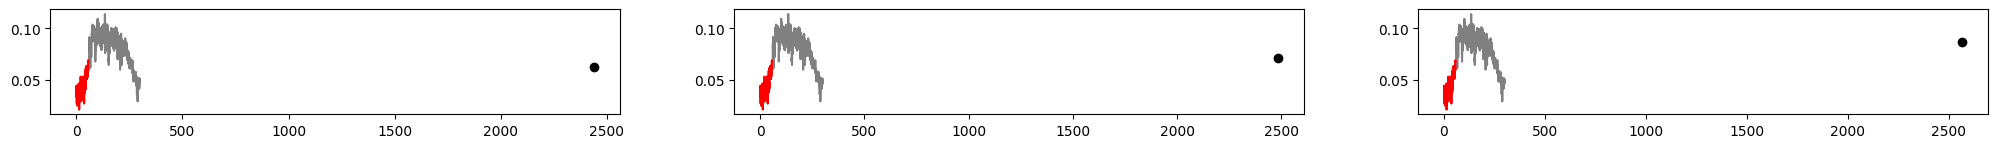

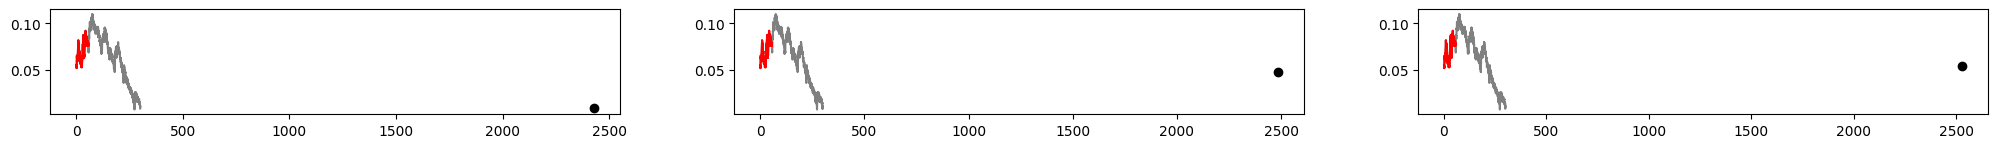

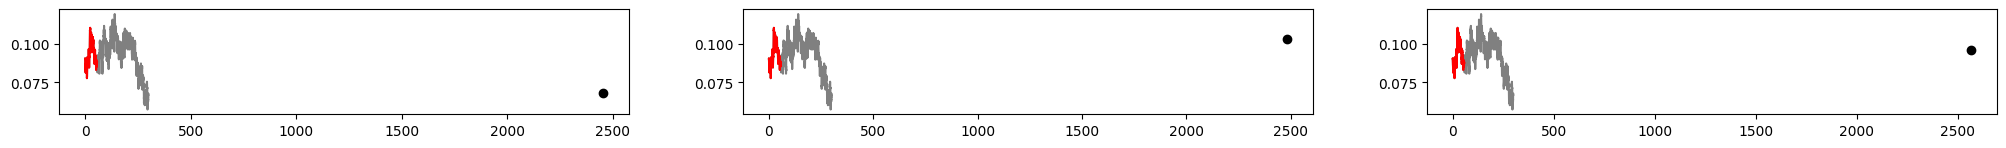

In [ ]:
for i,c in enumerate(KO_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax1.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax1.scatter(KO_saline_puff1_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax2.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax2.scatter(KO_saline_puff2_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i].index, KO_saline_dFF.iloc[:idx_of_the_nearest(time_, 300),i], color="gray")
    ax3.plot(KO_saline_dFF.index[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57)], KO_saline_dFF.iloc[idx_of_the_nearest(time_, 0):idx_of_the_nearest(time_, 57), i], color="red")
    ax3.scatter(KO_saline_puff3_peakInd_pre[i], KO_saline_dFF.loc[KO_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff1_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[0.03318000689339762,
 0.08463005411753599,
 0.0574521520421144,
 0.05869997235683211,
 0.043595080196152436,
 0.059431460598179386,
 0.10357227461033469,
 0.046205345483298466,
 0.0866820540440908]

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff2_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[0.04405651796948473,
 0.10814465778012894,
 0.03917721774278593,
 0.04826769820949406,
 0.016571294699275874,
 0.0437003255962376,
 0.07092077988248646,
 0.047110757679960535,
 0.10316244803538177]

In [ ]:
peak_func(KO_saline_dFF, KO_saline_puff3_peakInd_pre)

/tmp/ipykernel_62749/163390020.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  float(dFF_data.loc[peakInd[i], mouse])


[0.04117692863353484,
 0.09716420956372873,
 0.045956431995333724,
 0.061059830637651635,
 0.003860008835312345,
 0.04696135207490493,
 0.08648712709936968,
 0.054091903294655186,
 0.09559468805444771]

In [ ]:
KO_saline_dFF.to_excel('KO_saline_dFF.xlsx')

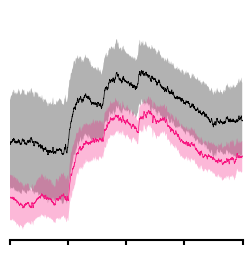

In [ ]:
##figures

Fig_start = idx_of_the_nearest(time_, 0)
Fig_end = idx_of_the_nearest(time_, 2700)

Cont_saline_mean = Cont_saline_dFF.mean(axis=1)
KO_saline_mean = KO_saline_dFF.mean(axis=1)

Cont_saline_SEM = Cont_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(Cont_saline_dFF.columns))
KO_saline_SEM = KO_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(KO_saline_dFF.columns))

plt.figure(figsize=(3,3))
plt.axvline(x=600, color='black', linestyle="--", linewidth=0.7, zorder=1)


plt.fill_between(Cont_saline_dFF.index[Fig_start:], Cont_saline_mean.iloc[Fig_start:] - Cont_saline_SEM.iloc[Fig_start:], \
                Cont_saline_mean.iloc[Fig_start:] + Cont_saline_SEM.iloc[Fig_start:], facecolor='black', lw = 0, alpha=0.3, zorder=2)
plt.plot(Cont_saline_mean.iloc[Fig_start:], lw = 0.5, color="black")

plt.fill_between(KO_saline_dFF.index[Fig_start:], KO_saline_mean.iloc[Fig_start:] - KO_saline_SEM.iloc[Fig_start:], \
                 KO_saline_mean.iloc[Fig_start:] + KO_saline_SEM.iloc[Fig_start:], facecolor='#f71580', lw = 0, alpha=0.3, zorder=2)
plt.plot(KO_saline_mean.iloc[Fig_start:], lw = 0.5, color="#f71580")

#plt.fill_between(Cont_saline_dFF.index[Fig_start:], Cont_saline_mean.iloc[Fig_start:] - Cont_saline_SEM.iloc[Fig_start:], \
#                Cont_saline_mean.iloc[Fig_start:] + Cont_saline_SEM.iloc[Fig_start:], facecolor='gray', lw = 0, alpha=0.3, zorder=2)
#plt.plot(Cont_saline_mean.iloc[Fig_start:], lw = 0.5, color="gray")

#plt.fill_between(KO_saline_dFF.index[Fig_start:], KO_saline_mean.iloc[Fig_start:] - KO_saline_SEM.iloc[Fig_start:], \
#                 KO_saline_mean.iloc[Fig_start:] + KO_saline_SEM.iloc[Fig_start:], facecolor='magenta', lw = 0, alpha=0.3, zorder=2)
#plt.plot(KO_saline_mean.iloc[Fig_start:], lw = 0.5, color="magenta")

plt.xlim(2300, 2700)
#plt.ylim(-0.03, 0.1)
#plt.xticks([2400, 2460, 2520])


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines["bottom"].set_linewidth(1.5)
plt.tick_params(length=3.5, width=1.5)
plt.tick_params(labelbottom=False, labelleft=False)
plt.tick_params(left=False, right=False, top=False)

#plt.savefig("cAMP_hab.png", format="png", dpi=300, transparent=True)

plt.show()